In [19]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os

In [20]:
ORIGINAL_FPS = 30
MANUAL_FPSS = ['3', '5', '10', '15', '30']
USE_MANUAL_FPSS = True
THRESHOLD = 0.75

In [21]:
interval = 4

In [22]:
accuracy_result_dict_paths = [
	'./result/plot_set/Scene-1-Day_Accuracy_Result.json',
	'./result/plot_set/Scene-1-Afternoon_Accuracy_Result.json',
	'./result/plot_set/Scene-1-Night_Accuracy_Result.json',
		'./result/plot_set/Scene-1-Midnight_Accuracy_Result.json',
]

In [23]:
movement_result_dict_paths = [
	'./result/plot_set/Scene-1-Day_Movement_Result.json',
	'./result/plot_set/Scene-1-Afternoon_Movement_Result.json',
	'./result/plot_set/Scene-1-Night_Movement_Result.json',
		'./result/plot_set/Scene-1-Midnight_Movement_Result.json',
]

In [24]:
colors = [
	'#e6194B',
	'#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
		'#f7cc1d',
]

In [25]:
def load_json(filepath):
	with open(filepath, 'r') as file:
		data = json.load(file)
		
	return data

In [26]:
def extract_fpss(metric_list, data_type='metric'):
	return list(metric_list[list(metric_list.keys())[0]][0][data_type].keys())

In [27]:
def extract_metric_list(metric_list, fpss, feature='F1', data_type='metric'):
	result_column = {}
		
	for fps in fpss:
		if data_type == 'metric':
			result_column[fps] = [clip_metric[data_type][fps][feature] for clip_metric in metric_list]
		elif data_type == 'movement':
			result_column[fps] = [clip_metric[data_type][fps] for clip_metric in metric_list]
		
	return result_column

In [28]:
def cumulative_sum_list(input_list):
	result = []
	total = 0
	for item in input_list:
		total += item
		result.append(total)
	return result

def extract_metric_time(metric_list):
	frame_number_list = [clip_metric['frame_count'] for clip_metric in metric_list]
	time_list = cumulative_sum_list(frame_number_list)
	time_list = list(np.array(time_list) - time_list[0])
	scaled_time_list = list(np.array(time_list) / ORIGINAL_FPS)

	return round_floats_to_sigfigs(scaled_time_list, 0)

In [29]:
def combine_times(matrix, interval):
		result = []
		new_len = math.floor(len(matrix) / interval)

		for i in range(new_len):
				result.append(np.average(np.array(matrix[i:i+interval])))
		
		return result

In [30]:
def plot_two_ys(xs, y1s, y2s, x_label, y1_label, y2_label, title, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color=colors[0], marker='o', label=y1_label)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color=colors[0], fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color=colors[3], marker='o', label=y2_label)  # 'o' denotes the marker type
	ax2.set_ylabel(y2_label, color=colors[3], fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

In [31]:
def dict_feature_idx(d, feature_idx):
	result_dict = {}
	for k in d.keys():
		result_dict[k] = [cf[feature_idx] for cf in d[k]]
	
	return result_dict

In [32]:
def average_of_lists_in_dict(data):
		"""
		Computes the average of corresponding elements across all lists in a dictionary.
		
		Args:
				data (dict): A dictionary where values are lists of the same length.
		
		Returns:
				list: A list of averages, with each element corresponding to the average of
							the respective index across all lists in the dictionary.
		"""
		# Ensure the dictionary is not empty
		if not data:
				return []

		# Extract the lists from the dictionary values
		lists = list(data.values())

		# Check that all lists have the same length
		if not all(len(lst) == len(lists[0]) for lst in lists):
				raise ValueError("All lists in the dictionary must be of the same length.")

		# Calculate the average for each index
		num_lists = len(lists)
		result = [
				sum(values) / num_lists
				for values in zip(*lists)
		]

		return result

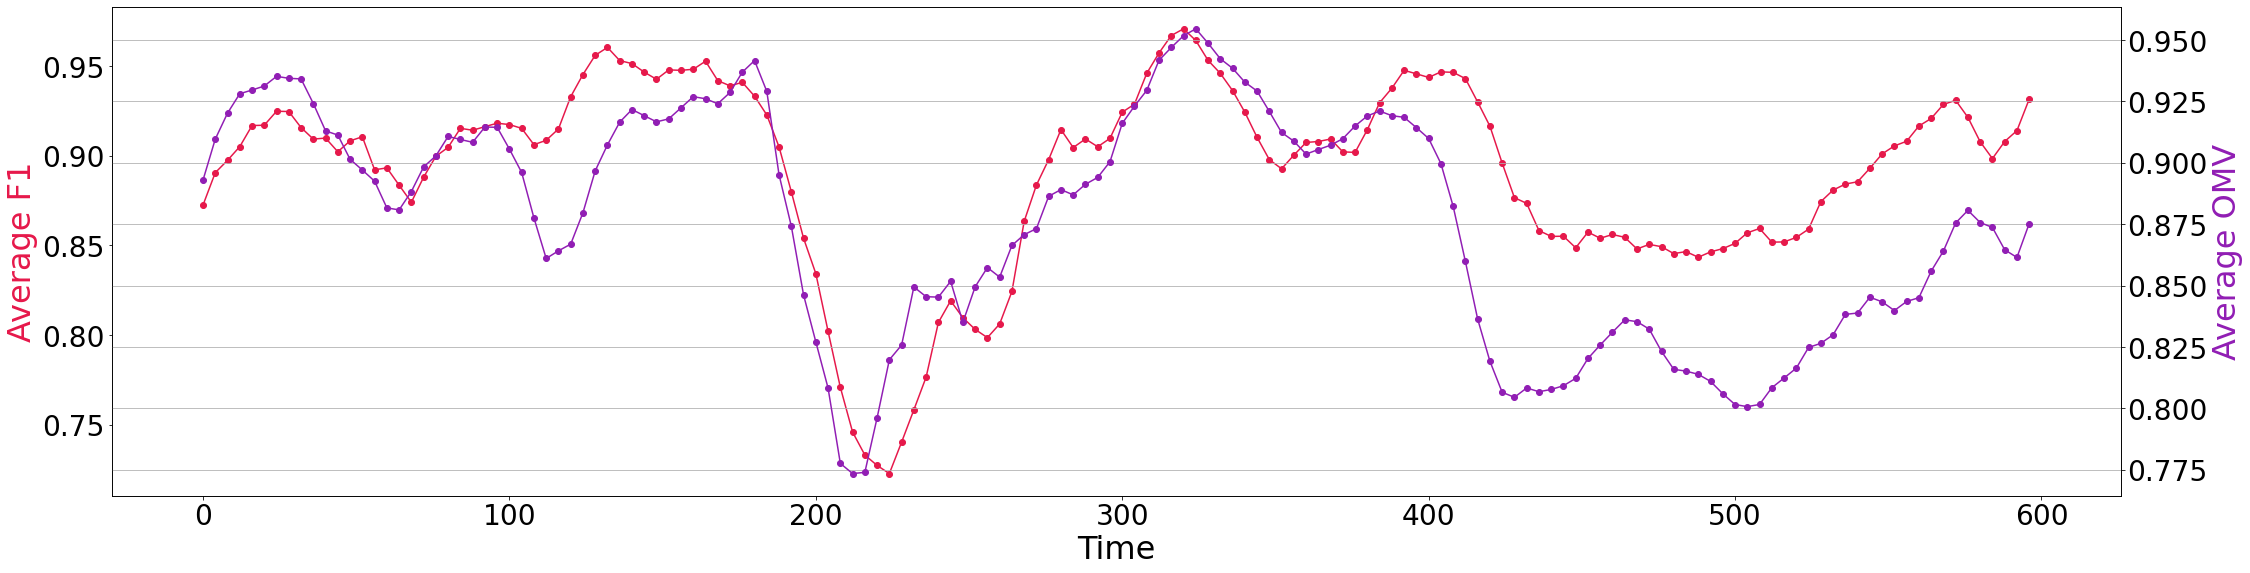

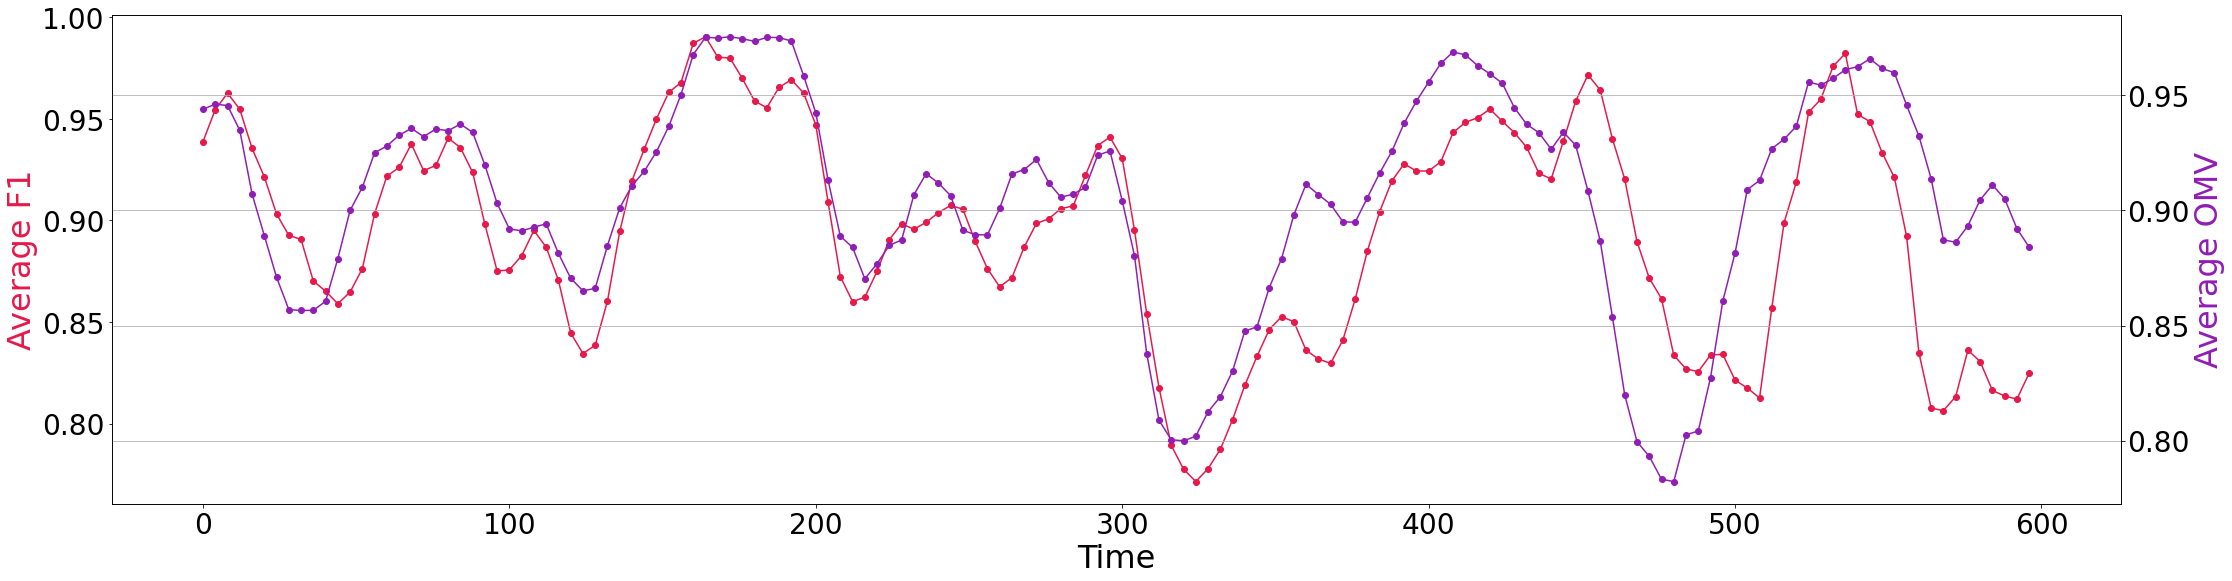

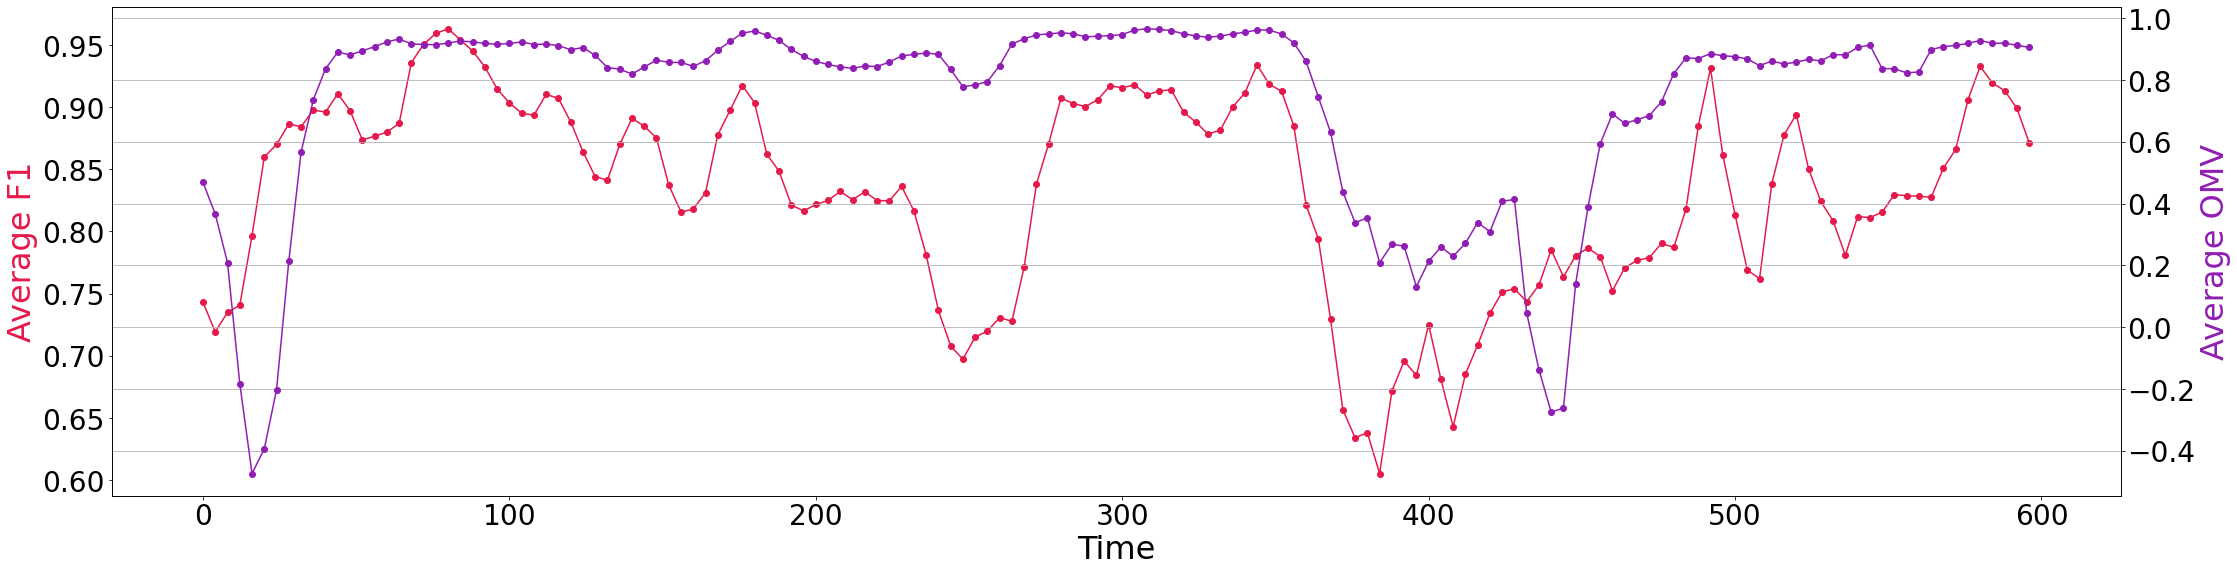

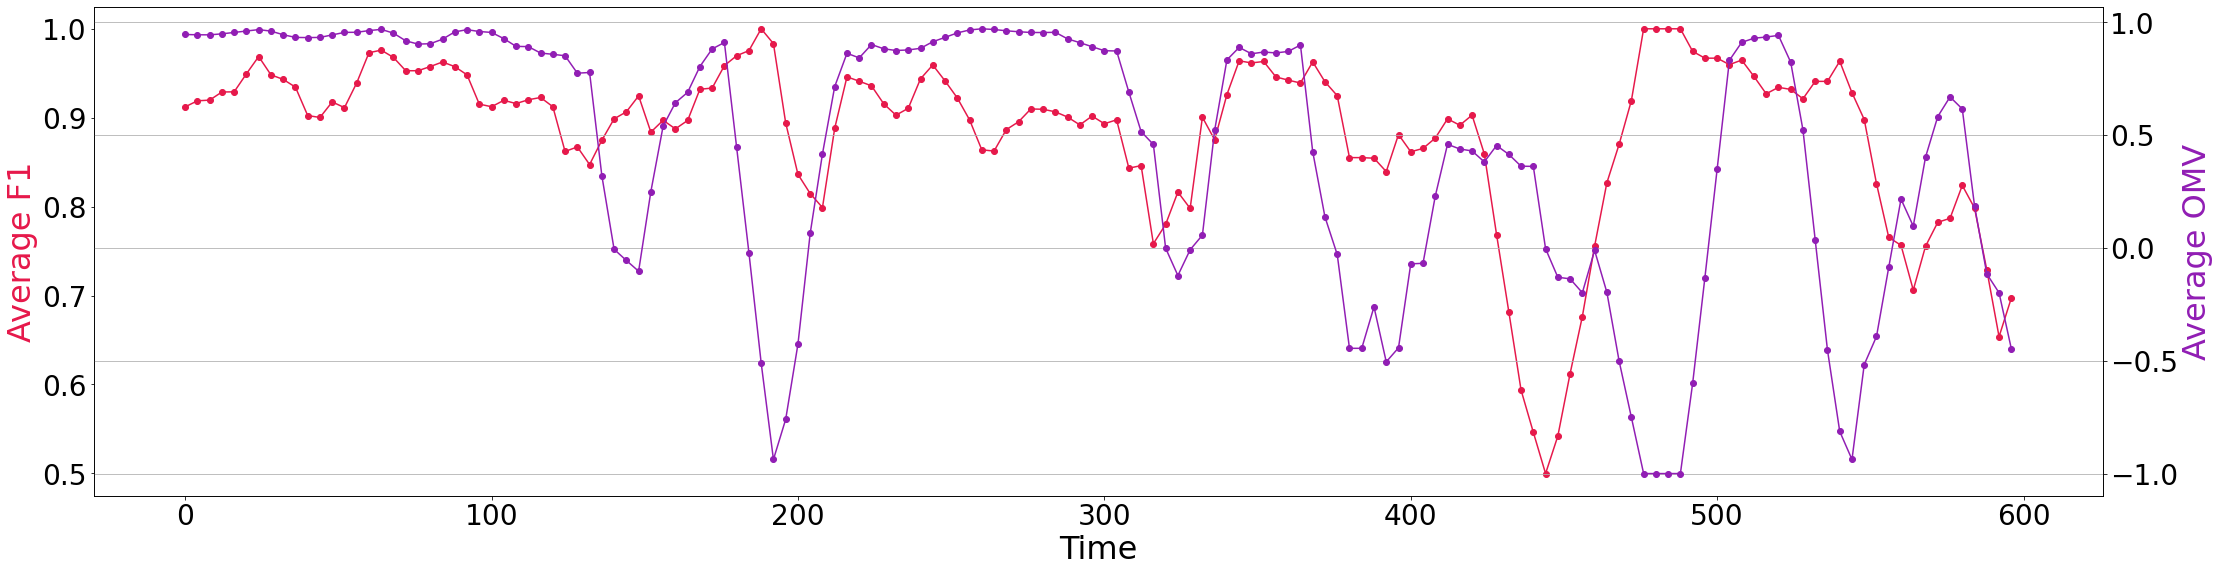

In [33]:
profiling_result = {}

for i in range(len(accuracy_result_dict_paths)):
	video_prefix = f'{os.path.splitext(os.path.basename(accuracy_result_dict_paths[i]))[0]}'
	video_prefix = video_prefix[0 : video_prefix.find('_')]
	profiling_result[video_prefix] = {}
	accuracy_result_dict_path = accuracy_result_dict_paths[i]
	accuracy_result_dict = load_json(accuracy_result_dict_path)
	
	fpss = extract_fpss(accuracy_result_dict)

	movement_result_dict_path = movement_result_dict_paths[i]
	movement_result_dict = load_json(movement_result_dict_path)

	for class_idx in list(accuracy_result_dict.keys()):
		accuracy_result = extract_metric_list(accuracy_result_dict[class_idx], fpss)
		movement_result = extract_metric_list(movement_result_dict[class_idx], fpss, data_type='movement')
		movement_result_feature_idx = dict_feature_idx(movement_result, 6) # Confidence

		avg_accuracy_result = average_of_lists_in_dict(accuracy_result)
		avg_movement_result = average_of_lists_in_dict(movement_result_feature_idx)

		combined_accuracy = combine_times(avg_accuracy_result, interval)
		combined_movement = combine_times(avg_movement_result, interval)
		time = list(np.array(range(len(combined_accuracy))) * interval)
		plot_two_ys(time, combined_accuracy, combined_movement, 'Time', 'Average F1', 'Average OMV', f'')

		profiling_result[video_prefix]['combined_accuracy'] = combined_accuracy
		profiling_result[video_prefix]['combined_confidence'] = combined_movement


### Detect Sudden Drop

In [34]:
def detect_sudden_drops(data, min_drops=3, drop_threshold=0.05, hold_after_drop=15):
    """
    Detects indices of sudden drops in a time-series, with a cooldown period after each detection.

    Args:
        data (list of float): The time-series data.
        min_drops (int): Minimum number of sequential drops to be considered a sudden drop.
        drop_threshold (float): Minimum magnitude of each drop to count towards a sequence.
        hold_after_drop (int): Number of data points to hold before detecting another drop.

    Returns:
        list of int: A list of indices where sudden drops occur.
    """
    sudden_drops = []
    drop_count = 0  # Counter for sequential drops
    i = 0  # Iterator

    while i < len(data) - 1:
        if i > 0 and data[i - 1] - data[i] > drop_threshold:
            drop_count += 1
            # If we reach the required number of drops, record the index
            if drop_count >= min_drops:
                sudden_drops.append(i)
                drop_count = 0  # Reset the counter
                i += hold_after_drop  # Skip the hold period
                continue
        else:
            drop_count = 0  # Reset the counter if the drop sequence is broken

        i += 1  # Increment index

    return sudden_drops

In [35]:
def plot_two_ys_highlight(xs, y1s, y2s, x_label, y1_label, y2_label, title, highlight_indices, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color=colors[0], marker='o', label=y1_label)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color=colors[0], fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color=colors[3], marker='o', label=y2_label)  # 'o' denotes the marker type

	# Highlight specific points on the second line
	if highlight_indices:
		for idx in highlight_indices:
			if 0 <= idx < len(xs):  # Ensure index is valid
				ax2.plot(xs[idx], y2s[idx], color=colors[4], marker='*', markersize=30, label=f"Highlight {idx}")

	ax2.set_ylabel(y2_label, color=colors[3], fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

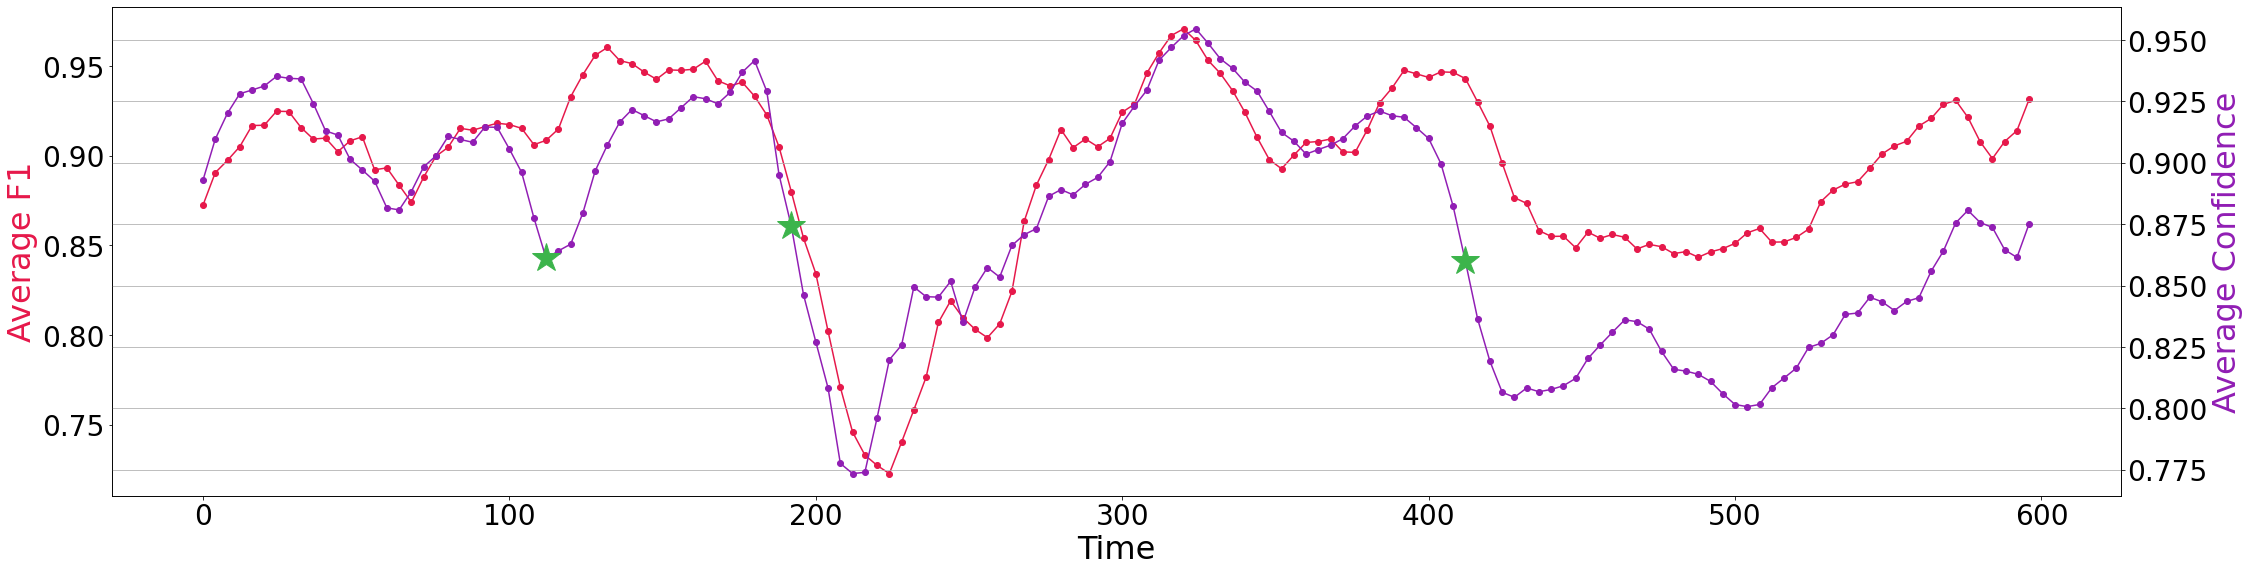

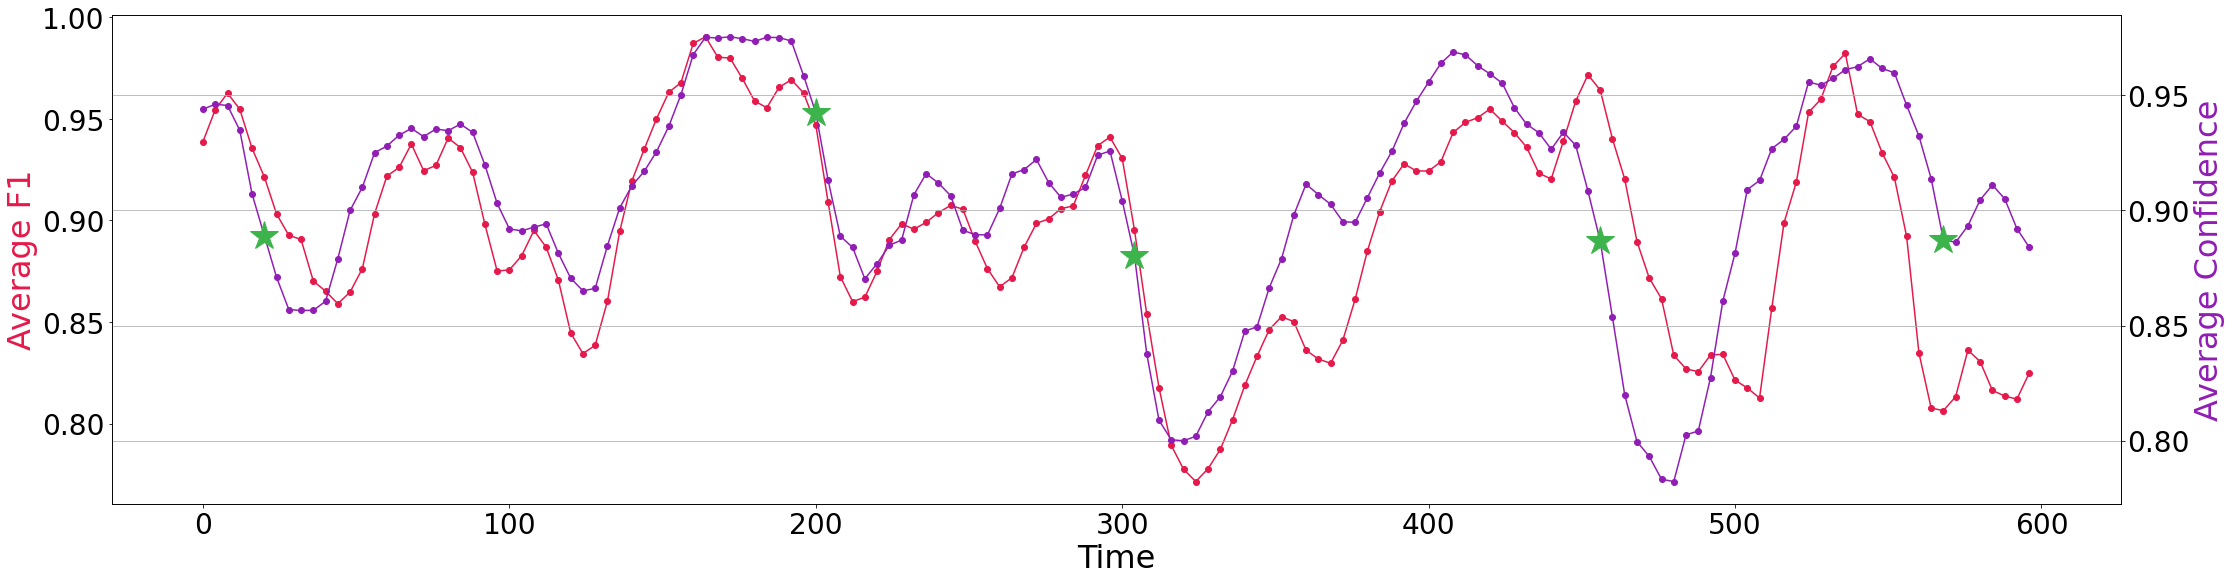

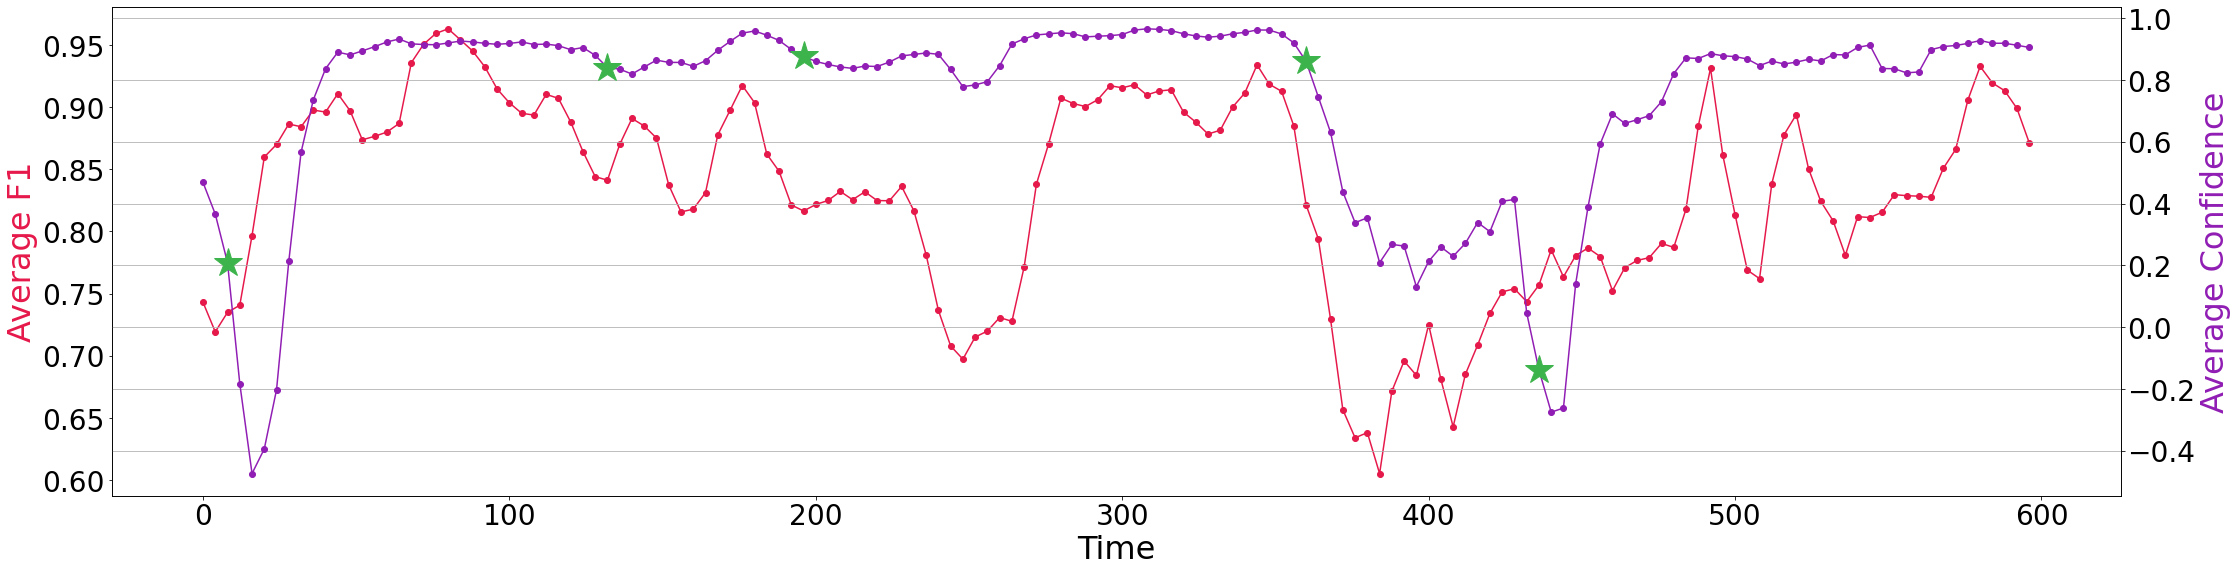

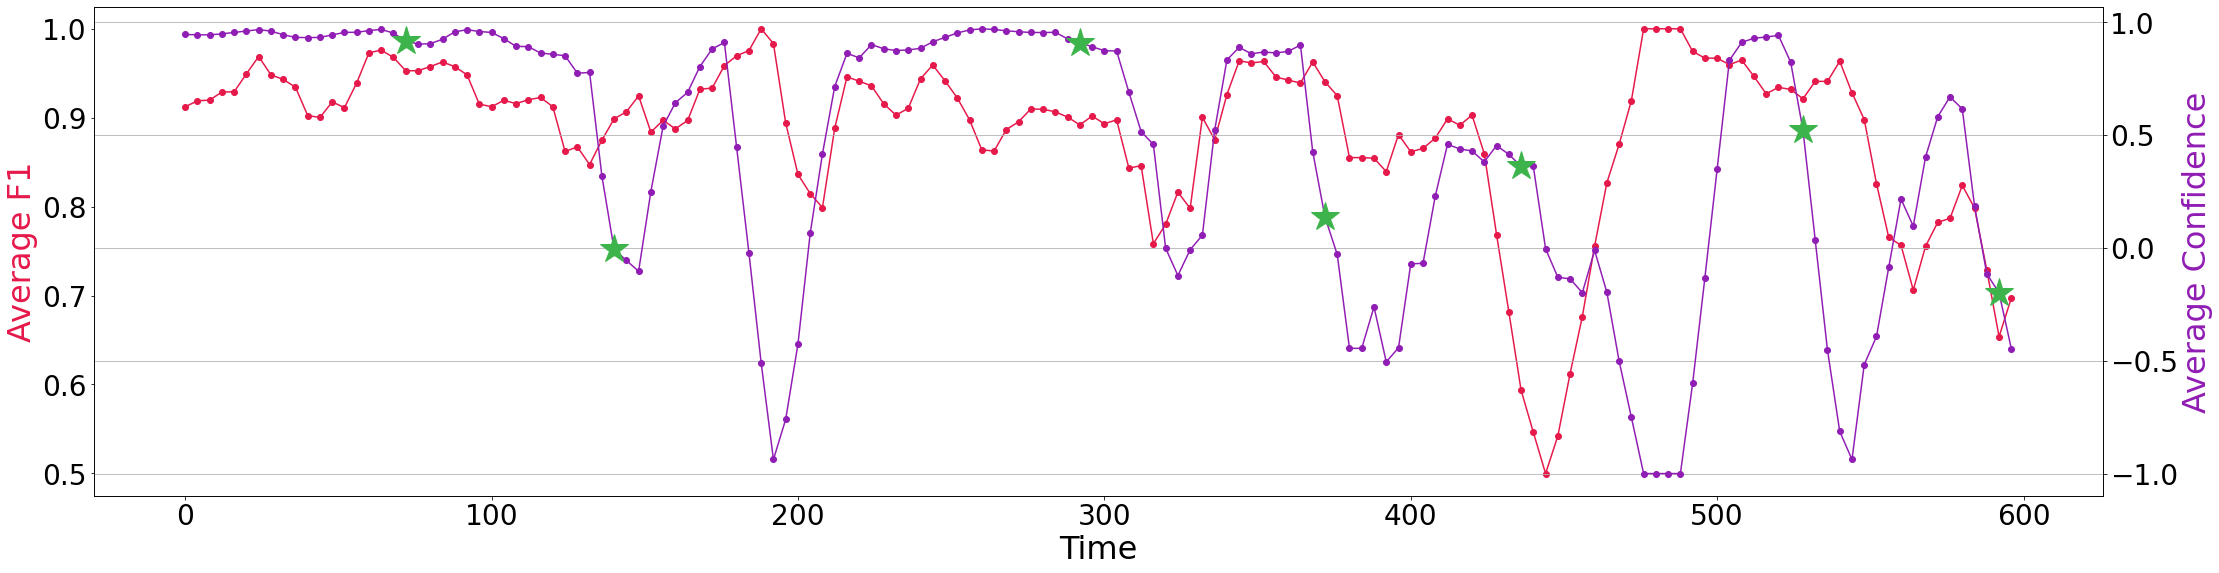

In [36]:
video_prefix = list(profiling_result.keys())

for vp in video_prefix:
	combined_accuracy = profiling_result[vp]['combined_accuracy']
	combined_confidence = profiling_result[vp]['combined_confidence']

	sudden_drop = detect_sudden_drops(combined_confidence, 2, 0.015, 15)

	plot_two_ys_highlight(time, combined_accuracy, combined_confidence, 'Time', 'Average F1', 'Average Confidence', f'', sudden_drop)